<a href="https://colab.research.google.com/github/jagminder92/FirstProject/blob/master/01_EDA_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1000, 10)
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object
                Age   Sex          Job Housing Saving accounts  \
count   1000.000000  1000  1000.000000    1000             915   
unique          NaN     2          NaN       3               4   
top             NaN  male          NaN     own          little   
freq            NaN   523          NaN     589             412   
mean      46.247000   NaN     1.306000     NaN             NaN   
std       16.288072   NaN     0.901763     NaN             NaN   
min       18.000000   NaN     0.000000     NaN             NaN   
25%       33.000000   NaN     1.000000     NaN             NaN   
50%       46.000000   NaN     1.000000     NaN             NaN   
75%       60.250000   NaN     2.000000     Na

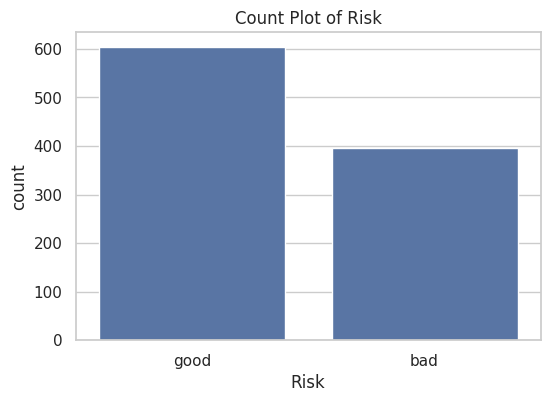

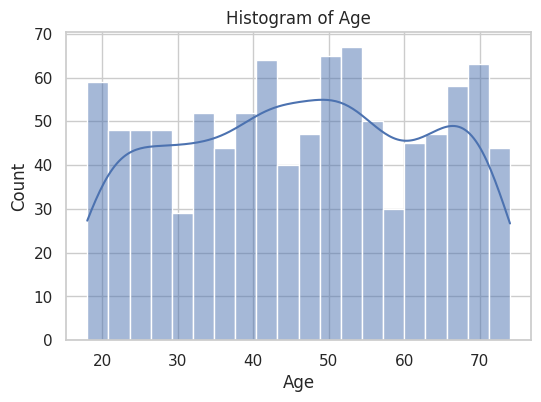

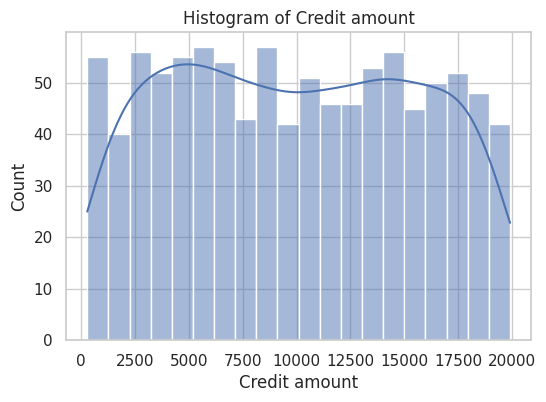

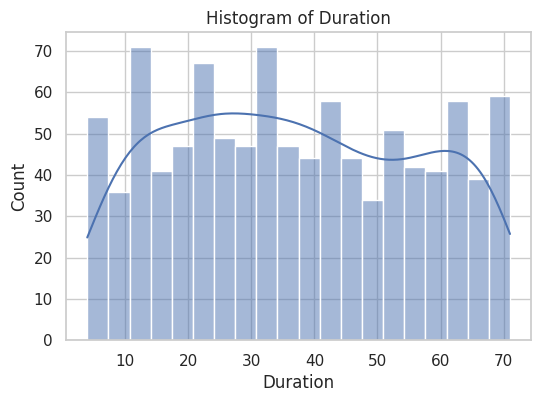

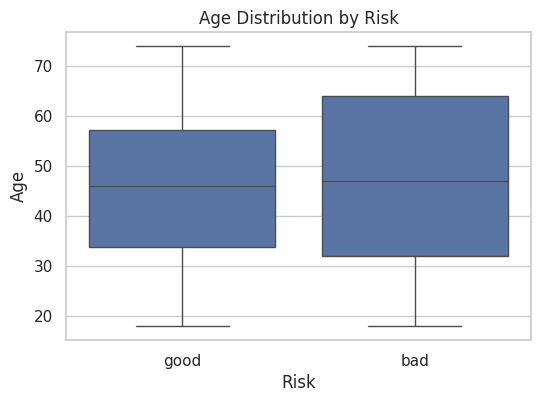

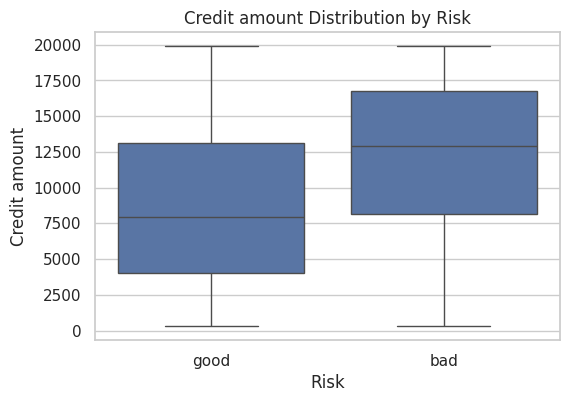

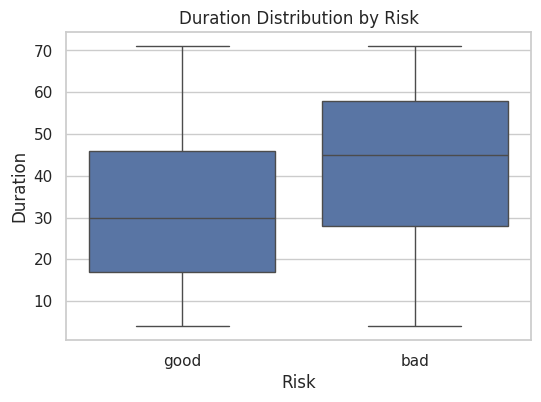

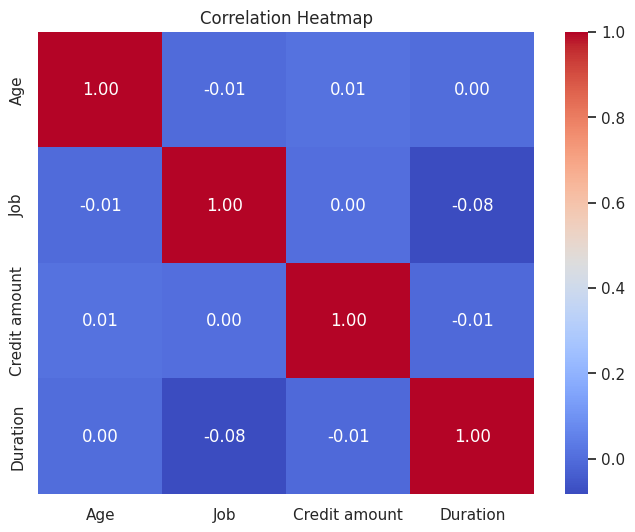

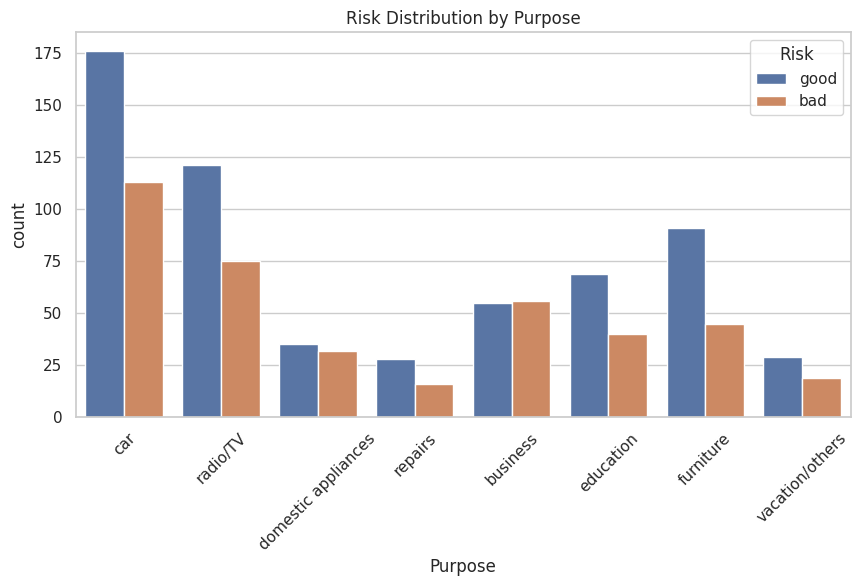

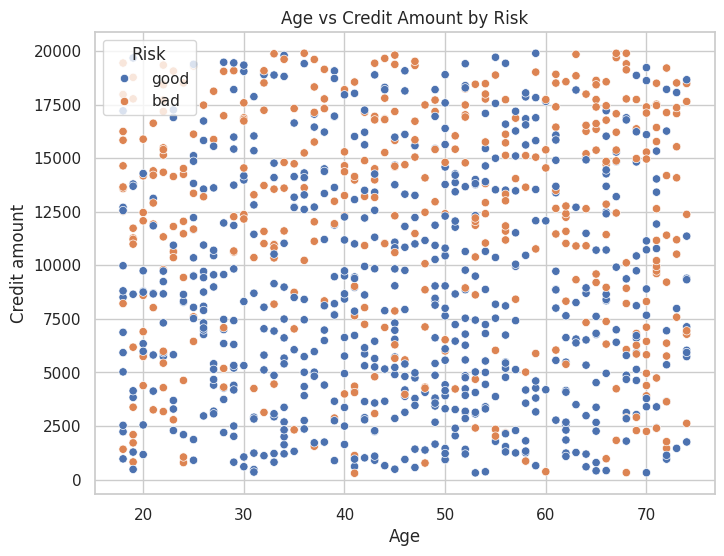

Training set shape: (800, 21)
Test set shape: (200, 21)
Target distribution (train):
Risk
0    484
1    316
Name: count, dtype: int64
   Credit_to_Duration_Ratio Age_Group  High_Risk_Purpose  Account_Stability
0                306.590909       50+                  0                  3
1                149.100000       50+                  0                  4
2               1220.375000     36-50                  0                  4
3                270.914286     26-35                  0                  3
4               1260.714286       50+                  0                  3


In [16]:
#Jagminder Singh
#ID= iitp_aiml_2506153
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load dataset
file_path = "/content/sample_data/german_credit_data.csv"
df = pd.read_csv(file_path)


print(df.shape)
print(df.dtypes)

print(df.describe(include='all'))


print("\n missing values")
missing = df.isnull().sum()
print(missing)

print("\nTotal Missing Values:", missing.sum())

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

#1plot of target var
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='Risk', data=df)
plt.title("Count Plot of Risk")
plt.show()

#2histogram
numerical_features = ['Age', 'Credit amount', 'Duration']

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

#3feature dist plot
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Risk', y=col, data=df)
    plt.title(f"{col} Distribution by Risk")
    plt.show()

#4coorelation map
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Risk vs Purpose visual
plt.figure(figsize=(10,5))
sns.countplot(x='Purpose', hue='Risk', data=df)
plt.xticks(rotation=45)
plt.title("Risk Distribution by Purpose")
plt.show()


#Age vs Credit Amount visual
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Credit amount', hue='Risk', data=df)
plt.title("Age vs Credit Amount by Risk")
plt.show()

#preprocessing- data values
df['Saving accounts'] = df['Saving accounts'].fillna('No account')
df['Checking account'] = df['Checking account'].fillna('No account')


# Encode Risk: good = 0, bad = 1
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

X = df.drop('Risk', axis=1)
y = df['Risk']
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=np.number).columns

# One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42

)
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Target distribution (train):")
print(y_train.value_counts())

#feature eng-
df["Credit_to_Duration_Ratio"] = df["Credit amount"] / df["Duration"]

bins = [18, 25, 35, 50, 100]
labels = ["18-25", "26-35", "36-50", "50+"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

high_risk_categories = ["education", "business", "repairs"]

df["High_Risk_Purpose"] = df["Purpose"].apply(
    lambda x: 1 if x in high_risk_categories else 0
)

account_score = {
    "No account": 0,
    "little": 1,
    "moderate": 2,
    "quite rich": 3,
    "rich": 4
}



df["Saving_score"] = df["Saving accounts"].map(account_score)
df["Checking_score"] = df["Checking account"].map(account_score)

df["Account_Stability"] = df["Saving_score"] + df["Checking_score"]

print(df[[
    "Credit_to_Duration_Ratio",
    "Age_Group",
    "High_Risk_Purpose",
    "Account_Stability"
]].head())








